____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, 15m_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, drifters_sources, assign_attrs, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# 15m

In [2]:
comb = [dict(drifter_key='nofilter', spectral_key='LF', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15', wd_model='rio'), 
        dict(drifter_key='nofilter', spectral_key='inertial', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15', wd_model='rio'), 
        dict(drifter_key='nofilter', spectral_key='', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15', wd_model='rio'), 
       ]

DS = dataset_coloc_combs(comb, nearest =False).dropna('row_number')
DSS = DS.where(DS.depth==15, drop=True)

DSS['time_to_swot_1h'] = DSS.time_to_swot/pd.Timedelta('1h')//1
list_h = np.unique(DSS.time_to_swot_1h)

/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


nofilter_LF__swot2kmnaive_etaf__rio_15era5


/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


nofilter_inertial__swot2kmnaive_etaf__rio_15era5


/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


nofilter___swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


In [3]:
D = []
for c in DSS.id_comb :
    dff = DSS.sel(id_comb=c).to_dataframe().reset_index().set_index('row_number')
    D.append(compute_mean_square_groupby(dff, groupby = 'time_to_swot_1h', compute_error = 'centrallimit'))
dss = xr.concat(D, pd.Index(['LF', 'Inertial', 'All'], name = 'frequency_band'))


X = ['X_acc_cor','X_acc_ggd','X_acc_wd','X_cor_ggd','X_cor_wd','X_ggd_wd']
xstyle = {l.replace('X_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in X}

dss['sX'] = dss[X[0]]
for x in X[1:]:
    dss['sX']= dss['sX']+dss[x]


In [4]:
def plot_error(df, x, v, ax, suf = 'ber__'):
    ax.fill_between(
        df[x], df[v] - df[suf + v], df[v] + df[suf + v], color="silver"
    )



Text(0.5, 0.98, '15m')

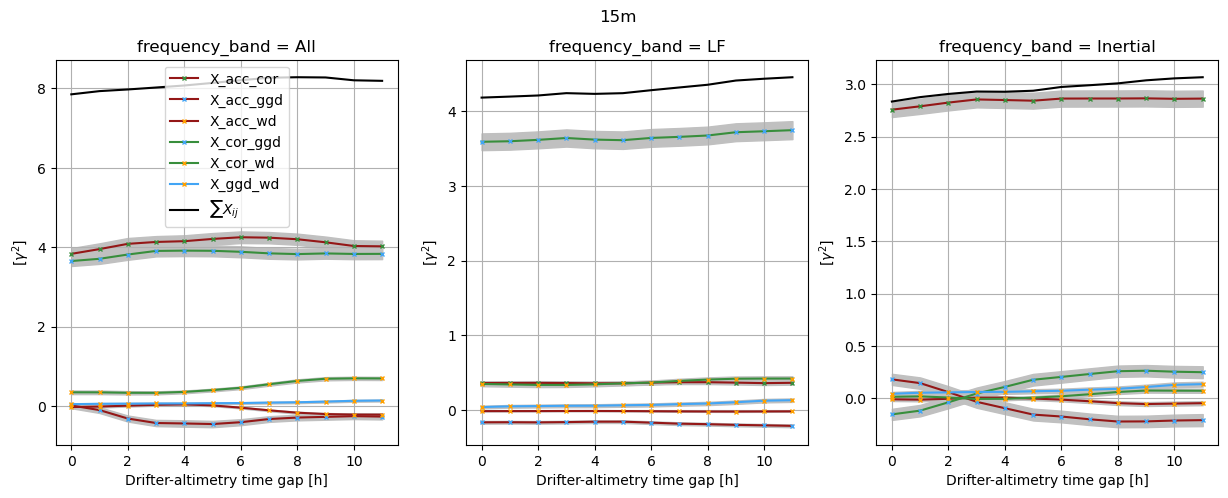

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15,5), frameon=False)

for x in X :
    dss.sel(frequency_band = 'All')[x].plot(label=x, **xstyle[x.replace('X_', '')], ax=axs[0])
    dss.sel(frequency_band = 'LF')[x].plot(label=x, **xstyle[x.replace('X_', '')], ax=axs[1])
    dss.sel(frequency_band = 'Inertial')[x].plot( label=x, **xstyle[x.replace('X_', '')], ax=axs[2])
    plot_error(dss.sel(frequency_band = 'All'),'time_to_swot_1h', x, axs[0], suf = 'ser__')
    plot_error(dss.sel(frequency_band = 'LF'),'time_to_swot_1h', x, axs[1], suf = 'ser__')
    plot_error(dss.sel(frequency_band = 'Inertial'),'time_to_swot_1h', x, axs[2], suf = 'ser__')
    
dss.sel(frequency_band = 'All').sX.plot(c='k', label = r'$\sum X_{ij}$', ax=axs[0])
dss.sel(frequency_band = 'LF').sX.plot(c='k', ax=axs[1])
dss.sel(frequency_band = 'Inertial').sX.plot(c='k', ax=axs[2])

axs[0].legend()

for ax in axs : 
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xlabel('Drifter-altimetry time gap [h]')
fig.suptitle('15m')


Text(0.5, 0.98, '15m')

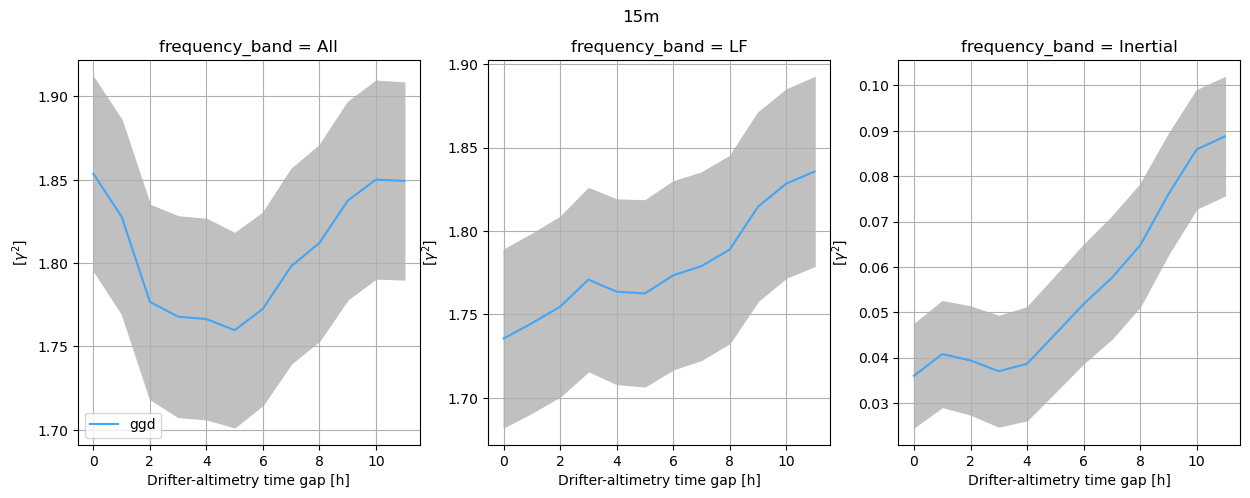

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15,5), frameon=False)

for v in ['ggd'] :
    dss.sel(frequency_band = 'All')['B_'+v].plot(label=v, c=c0[v], ax=axs[0])
    dss.sel(frequency_band = 'LF')['B_'+v].plot(label=v, c=c0[v], ax=axs[1])
    dss.sel(frequency_band = 'Inertial')['B_'+v].plot( label=v, c=c0[v], ax=axs[2])
    plot_error(dss.sel(frequency_band = 'All'),'time_to_swot_1h','B_'+v, axs[0], suf = 'ser__')
    plot_error(dss.sel(frequency_band = 'LF'),'time_to_swot_1h', 'B_'+v, axs[1], suf = 'ser__')
    plot_error(dss.sel(frequency_band = 'Inertial'),'time_to_swot_1h', 'B_'+v, axs[2], suf = 'ser__')
    
#dss.sel(frequency_band = 'All').sX.plot(c='k', label = r'$\sum X_{ij}$', ax=axs[0])
#dss.sel(frequency_band = 'LF').sX.plot(c='k', ax=axs[1])
#dss.sel(frequency_band = 'Inertial').sX.plot(c='k', ax=axs[2])

axs[0].legend()

for ax in axs : 
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xlabel('Drifter-altimetry time gap [h]')

fig.suptitle('15m')
